In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import pandas as pd

transform = transforms.Compose([
    transforms.ToPILImage(), # Convert NumPy array to PIL Image
    transforms.Resize((32, 32), antialias=True),
    transforms.RandomRotation(10),
    transforms.ToTensor(), # Convert PIL Image to Tensor and normalize to [0, 1]
])

# Load MNIST dataset
test_df = pd.read_csv('/content/sign_mnist_test.csv')
train_df = pd.read_csv('/content/sign_mnist_train.csv')

In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

class MNISTDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # 1. Get the RAW INTEGER label from the dataframe
        label = int(row.iloc[0])

        # 2. MATHEMATICAL FIX: Shift the integer to close the gap left by 'J' (9)
        # This makes our labels perfectly continuous from 0 to 23,
        # preventing the "CUDA error: device-side assert triggered" crash!
        if label > 9:
            label -= 1

        # 3. Extract and reshape the image
        # We use 'uint8' because PyTorch's transforms.ToTensor() expects it
        # in order to automatically convert it to a float and divide by 255.0
        image = row[1:].values.astype(np.uint8).reshape(28, 28)

        # 4. Apply your transformations (ToPILImage, Resize, ToTensor, etc.)
        if self.transform:
            image = self.transform(image)
        else:
            # Fallback just in case you don't pass a transform
            image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0

        # Return the transformed image and the corrected integer label
        return image, label

In [ ]:
from sklearn.model_selection import train_test_split


train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

In [ ]:
train_dataset = MNISTDataset(train_split_df, transform=transform)
val_dataset = MNISTDataset(val_split_df, transform=transform)
test_dataset = MNISTDataset(test_df, transform=transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class AdvancedSignLanguageModel(nn.Module):
    def __init__(self, num_classes=24):
        super(AdvancedSignLanguageModel, self).__init__()

        self.densenet = models.densenet121(weights=None)
        self.densenet.features.conv0 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=3, # Reduced from 7
            stride=1,      # Reduced from 2
            padding=1,
            bias=False
        )

        # Remove the initial MaxPool layer entirely to preserve 28x28 spatial resolution
        self.densenet.features.pool0 = nn.Identity()

        # 3. Modify the Final Layer (Output)
        # DenseNet outputs 1000 classes by default. We change it to our 24 sign language classes.
        num_ftrs = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.densenet(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = AdvancedSignLanguageModel(num_classes=24).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)


In [ ]:
import torch
import numpy as np

class EarlyStopping:
    def __init__(self, patience=3, delta=0.0):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
        """
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

In [ ]:
import time
early_stopper = EarlyStopping(patience=7, delta=0.01)
print(f"Training on device: {device}")

model = AdvancedSignLanguageModel(num_classes=24).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 15
epoch_losses = []
epoch_accuracies = []
val_losses = []
val_accuracies = []

print("Starting Training...")

for epoch in range(epochs):
    epoch_start_time = time.time()
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    epoch_losses.append(avg_train_loss)
    epoch_accuracies.append(train_accuracy)

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0


    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time


    mins = int(epoch_duration // 60)
    secs = int(epoch_duration % 60)

    # Print epoch statistics (Now including time)
    print(f"Epoch [{epoch+1}/{epochs}] | Time: {mins}m {secs}s | LR: {current_lr:.6f}")

    #print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_accuracy:.2f}%")
    print("-" * 30)

    early_stopper(avg_val_loss)
    if early_stopper.early_stop:
        print("Early stopping used")
        break

Training on device: cuda
Starting Training...
Epoch [1/15] | Time: 0m 50s | LR: 0.001000
Train Loss: 0.5976 | Train Acc: 82.04%
Val Loss:   0.0901 | Val Acc:   97.63%
------------------------------
Epoch [2/15] | Time: 0m 50s | LR: 0.001000
Train Loss: 0.0401 | Train Acc: 98.88%
Val Loss:   0.0427 | Val Acc:   98.91%
------------------------------
Epoch [3/15] | Time: 0m 50s | LR: 0.001000
Train Loss: 0.0245 | Train Acc: 99.29%
Val Loss:   0.0113 | Val Acc:   99.69%
------------------------------
Epoch [4/15] | Time: 0m 50s | LR: 0.001000
Train Loss: 0.0081 | Train Acc: 99.81%
Val Loss:   0.0285 | Val Acc:   99.18%
------------------------------
EarlyStopping counter: 1 out of 7
Epoch [5/15] | Time: 0m 50s | LR: 0.000500
Train Loss: 0.0020 | Train Acc: 99.98%
Val Loss:   0.0002 | Val Acc:   100.00%
------------------------------
Epoch [6/15] | Time: 0m 50s | LR: 0.000500
Train Loss: 0.0003 | Train Acc: 100.00%
Val Loss:   0.0001 | Val Acc:   100.00%
------------------------------
Early

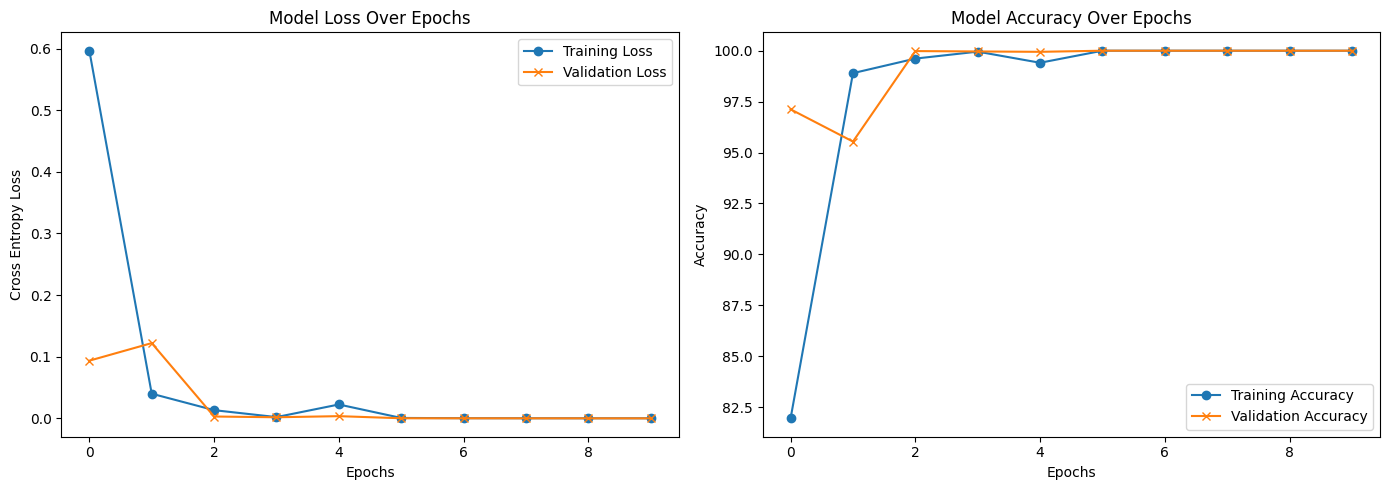

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Training vs. Validation Loss ---
axes[0].plot(epoch_losses, label='Training Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='x')
axes[0].set_title('Model Loss Over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross Entropy Loss')
axes[0].legend()
#axes[0].grid(True)

# --- Plot 2: Training vs. Validation Accuracy ---
axes[1].plot(epoch_accuracies, label='Training Accuracy', marker='o')
axes[1].plot(val_accuracies, label='Validation Accuracy', marker='x')
axes[1].set_title('Model Accuracy Over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
#axes[1].grid(True)

# Adjust layout to prevent overlap and display the plots
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Setup Device & Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

model = AdvancedSignLanguageModel(num_classes=24).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# 2. Lists to track metrics for the final graphs
epochs = 15
epoch_losses = []
epoch_accuracies = []

# 3. Training Loop (Train Set Only)
print("Starting Training...")
for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct_train = 0
    total_train = 0
    current_lr = scheduler.get_last_lr()[0]

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = 100 * correct_train / total_train

    epoch_losses.append(avg_loss)
    epoch_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f} | Train Loss: {avg_loss:.4f} | Train Acc: {accuracy:.2f}%")


In [ ]:


# Create a figure with 2 subplots (side by side)
plt.figure(figsize=(12, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', color='red', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 2: Training Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), epoch_accuracies, marker='o', color='blue', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Adjust layout and save/show the plot
plt.tight_layout()
plt.savefig('training_metrics.png')  # Saves the image to your files
plt.show()  # Displays the image in Jupyter/Colab

#TEST

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

correct_test = 0
total_test = 0

print(f"Evaluating model on {len(test_dataset)} test images...")

with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
test_accuracy = 100 * correct_test / total_test

print(f"FINAL TEST ACCURACY: {test_accuracy:.2f}%")

Evaluating model on 7172 test images...
FINAL TEST ACCURACY: 99.97%
